<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/synapses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Make nicer plots -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

## Adaptive Exponential Integrate-and-Fire neuronal (aEIF) model

\begin{align}
C_m \frac{dV}{dt} &= -g_L (V-E_L) + g_L \Delta_T \text{exp} \left( \frac{V-V_T}{\Delta_T} \right) - w + I_e + I_{syn} \\
\tau_w \frac{dw}{dt} &= \alpha (V-E_L) - w
\end{align}

- where $C_m$ is the membrane capacitance, $g_L$ and $E_L$ are the leak conductance and reversal potential, reespectively.

- $\Delta_T$ controls the sharpness of action potential initiation (typical values $ \sim 1 mV$ for pyramidal neurons), $V_T$ denotes the intrinsic membrane potential threshold. Once the membrane potential crosses $V_{T}$, it diverges to infinity in finite time. In numerical simulation the integration is stopped if the membrane potential hits an arbitrary threshold $V_{peak}$ (much larger than $V_{T}$) at which the membrane potential is reset to a value $V_r$.

- $\tau_w$ is the time constant and $\alpha$ represents the level of **subthreshold adaptation**. At each firing time, the variable $w$ is increased by anamount $b$, which accounts for **spike-triggered adaptation**.

Spike mechanism:

\begin{equation}
\text{if } V \ge V_{peak} \text{ then } V → V_r, w → w + b
\end{equation}

### Synapses in derivative form

\begin{equation}
g_{syn}(t) = \bar{g}_{syn} \left( \text{exp} \left( -\frac{t-t_{sp}}{\tau_d} \right) - \text{exp} \left( -\frac{t-t_{sp}}{\tau_r} \right) \right)
\end{equation}

In dynamical systems, this is translated into:

\begin{align}
\frac{dg_{syn}}{dt} &= -\frac{g_{syn}}{\tau_d} + x_{syn}\\
\frac{dx_{syn}}{dt} &= -\frac{x_{syn}}{\tau_r}\\
\end{align}

At every presynaptic spike: $x_{syn} += 1$

In [12]:
# Simulation parameters
T = 1000  # ms
dt = 0.1  # ms
steps = int(T/dt)
t_vec = np.linspace(0, T, steps+1)

In [13]:
# Model Parameters
C = 300  # membrane capacitance in pF
gL = 15  # leaky conductance in nS
EL = -70  # leaky reversal potential in mV

VT = -54  # threshold in mV
DeltaT = 2  # AP sharpness (slope factor) in mV
Vr = -80  # reset in mV
Vpeak = 20 # peak potential (detection limit) in mV

# Adaptation
tau_w = 144 # adaptation time constant in ms
alpha = 4  # subthreshold adaptation in nS
b = 80.5 # spike-triggered adaptation in pA

# Refractory period
tref = 20  # refractory period in ms

In [14]:
# Synaptic parameters
pre_spikes = [100]

tau_rise = 6  # rise time in ms
tau_decay = 12  # decay time in ms
g_bar = 1  # maximum conductance in nS
E_syn = 0  # synaptic reversal potential in mV

In [15]:
def normalize(tau1, tau2):
  tpeak = (tau1*tau2)/(tau2 - tau1) * np.log(tau2/tau1)
  peak = (tau1*tau2)/(tau2-tau1)*(np.exp(-tpeak/tau2) - np.exp(-tpeak/tau1))
  return 1/peak

In [16]:
normalize(tau_rise, tau_decay)

0.3333333333333333

In [20]:
V_aEIF = np.zeros((len(t_vec), ))
V_aEIF[0] = EL
w = np.zeros((len(t_vec), ))
w[0] = 0
gsyn = np.zeros((len(t_vec), ))
gsyn[0] = 0
xsyn = np.zeros((len(t_vec), ))
xsyn[0] = 0

tspike = [-1]
flag = True
Isyn = 0

for n in range(steps):

  # Presynaptic spike
  if np.round(n*dt, 1) in pre_spikes:
    xsyn[n] += g_bar*normalize(tau_rise, tau_decay)

  # Synapse
  Isyn = gsyn[n]*(V_aEIF[n] - E_syn)
  
  # Membrane
  deriv = (-gL*(V_aEIF[n]-EL) + gL*DeltaT*np.exp((V_aEIF[n]-VT)/DeltaT) - w[n] - Isyn)/C
  V_aEIF[n+1] = V_aEIF[n] + dt*deriv
  # Adaptation
  deriv_w = (alpha*(V_aEIF[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*deriv_w

  deriv_g = -gsyn[n]/tau_decay + xsyn[n]
  deriv_x = -xsyn[n]/tau_rise
  gsyn[n+1] = gsyn[n] + dt*deriv_g
  xsyn[n+1] = xsyn[n] + dt*deriv_x

  # Spike mechanism
  if V_aEIF[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V_aEIF[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V_aEIF[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

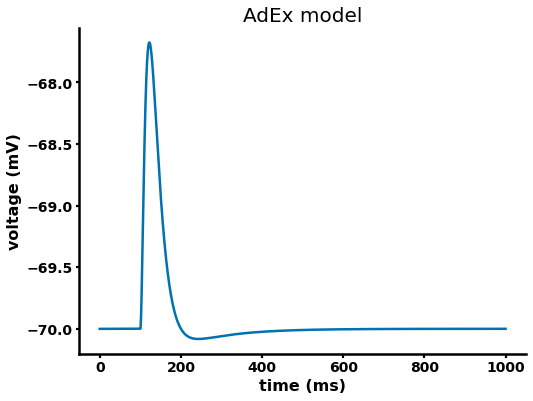

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V_aEIF)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.title('AdEx model')
plt.show()

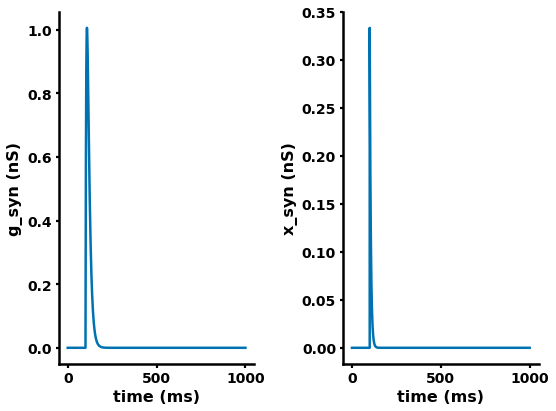

In [22]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(t_vec, gsyn)
plt.xlabel('time (ms)')
plt.ylabel('g_syn (nS)')
plt.subplot(1, 2, 2)
plt.plot(t_vec, xsyn)
plt.xlabel('time (ms)')
plt.ylabel('x_syn (nS)')

plt.tight_layout()
plt.show()

In [11]:
np.max(gsyn)

12.017301442617079